# Phase 4 — Primary Models

This notebook trains the improved Phase 4 models:
- Prophet for C1a and C2
- LightGBM for C0 and C1b
- DeepAR placeholder / setup for C3

The goal is to beat the Phase 3 baseline WMAPE values saved in `data/baselines/`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error
from lightgbm import LGBMRegressor

DATA = Path("../data")
OUT = DATA / "primary_models"
OUT.mkdir(exist_ok=True)

RANDOM_STATE = 42

In [2]:
train_raw = pd.read_parquet(DATA / "daily_train_clustered.parquet")
val_raw   = pd.read_parquet(DATA / "daily_val_clustered.parquet")
test_raw  = pd.read_parquet(DATA / "daily_test_clustered.parquet")

train_w = pd.read_parquet(DATA / "daily_train_clustered_winsorized.parquet")
val_w   = pd.read_parquet(DATA / "daily_val_clustered_winsorized.parquet")

history_raw = pd.concat([train_raw, val_raw], ignore_index=True)
history_w   = pd.concat([train_w, val_w], ignore_index=True)

print("Raw history:", history_raw.shape)
print("Winsorized history:", history_w.shape)
print("Test:", test_raw.shape)

print(test_raw["cluster"].value_counts(dropna=False).sort_index())

Raw history: (910092, 17)
Winsorized history: (910092, 17)
Test: (319652, 17)
cluster
0.0     80855
1.0     49769
2.0      1570
3.0    159669
4.0      1256
5.0     24492
NaN      2041
Name: count, dtype: int64


In [3]:
def wmape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.sum(np.abs(y_true))
    if denom == 0:
        return np.nan
    return np.sum(np.abs(y_true - y_pred)) / denom


def eps_mape(y_true, y_pred, eps=1.0):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs(y_true - y_pred) / np.maximum(np.abs(y_true), eps))


def nz_mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / np.abs(y_true[mask]))


def evaluate_predictions(df, pred_col="yhat", label="model"):
    y = df["total_sales"].values
    pred = np.clip(df[pred_col].values, 0, None)

    return {
        "model": label,
        "n_rows": len(df),
        "n_products": df["product_family_name"].nunique(),
        "WMAPE": wmape(y, pred),
        "eps_MAPE": eps_mape(y, pred),
        "NZ_MAPE": nz_mape(y, pred),
        "MAE": mean_absolute_error(y, pred),
        "zero_rate": (df["total_sales"] == 0).mean(),
    }

In [4]:
baseline_targets = pd.DataFrame([
    {"cluster": "C0",  "baseline_to_beat": "TSB",     "WMAPE": 1.080},
    {"cluster": "C1a", "baseline_to_beat": "iMAPA",   "WMAPE": 0.958},
    {"cluster": "C1b", "baseline_to_beat": "iMAPA",   "WMAPE": 1.029},
    {"cluster": "C2",  "baseline_to_beat": "AutoETS", "WMAPE": 0.939},
    {"cluster": "C3",  "baseline_to_beat": "iMAPA",   "WMAPE": 1.105},
    {"cluster": "C4",  "baseline_to_beat": "SWLY",    "WMAPE": 1.166},
])

baseline_targets

,cluster,baseline_to_beat,WMAPE
0,C0,TSB,1.080
1,C1a,iMAPA,0.958
2,C1b,iMAPA,1.029
3,C2,AutoETS,0.939
4,C3,iMAPA,1.105
5,C4,SWLY,1.166


In [5]:
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except ImportError:
    PROPHET_AVAILABLE = False
    print("Prophet is not installed. Run: pip install prophet")

In [6]:
def run_prophet_cluster(history_df, test_df, cluster_value, cluster_name):
    """
    Fits one Prophet model per product family in a cluster.
    Uses winsorized train+val history for training.
    Evaluates against raw test actuals.
    """
    if not PROPHET_AVAILABLE:
        raise ImportError("Prophet is not installed. Run: pip install prophet")

    hist = history_df[history_df["cluster"] == cluster_value].copy()
    test = test_df[test_df["cluster"] == cluster_value].copy()

    products = sorted(test["product_family_name"].unique())
    all_preds = []

    print(f"Running Prophet for {cluster_name}: {len(products)} products")

    for i, product in enumerate(products, 1):
        h = hist[hist["product_family_name"] == product].copy()
        t = test[test["product_family_name"] == product].copy()

        if h["total_sales"].sum() == 0 or len(h) < 30:
            # fallback: product has too little useful history
            fallback = h["total_sales"].tail(7).mean()
            temp = t[["product_family_name", "date", "total_sales"]].copy()
            temp["yhat"] = fallback
            temp["model"] = "prophet_fallback_mean7"
            all_preds.append(temp)
            continue

        train_p = h.rename(columns={"date": "ds", "total_sales": "y"})[["ds", "y"]].copy()

        m = Prophet(
            weekly_seasonality=True,
            yearly_seasonality=True,
            daily_seasonality=False,
            seasonality_mode="additive",
            changepoint_prior_scale=0.05,
        )

        m.fit(train_p)

        future = t.rename(columns={"date": "ds"})[["ds"]].copy()
        forecast = m.predict(future)

        temp = t[["product_family_name", "date", "total_sales"]].copy()
        temp["yhat"] = forecast["yhat"].values
        temp["yhat"] = temp["yhat"].clip(lower=0)
        temp["model"] = "prophet"
        all_preds.append(temp)

        if i % 25 == 0:
            print(f"  completed {i}/{len(products)} products")

    result = pd.concat(all_preds, ignore_index=True)
    metrics = evaluate_predictions(result, pred_col="yhat", label=f"Prophet_{cluster_name}")

    return result, metrics

### ❌ Prophet for C1a (deprecated)

We tested Prophet for C1a but it underperformed relative to baseline and LGBM, so it is not used in the final model selection.

In [7]:
c1a_prophet_preds, c1a_prophet_metrics = run_prophet_cluster(
    history_df=history_w,
    test_df=test_raw,
    cluster_value=1,
    cluster_name="C1a"
)

c1a_prophet_preds.to_parquet(OUT / "c1a_prophet_predictions.parquet", index=False)
c1a_prophet_metrics

18:43:48 - cmdstanpy - INFO - Chain [1] start processing


Running Prophet for C1a: 317 products


18:43:48 - cmdstanpy - INFO - Chain [1] done processing
18:43:48 - cmdstanpy - INFO - Chain [1] start processing
18:43:48 - cmdstanpy - INFO - Chain [1] done processing
18:43:49 - cmdstanpy - INFO - Chain [1] start processing
18:43:49 - cmdstanpy - INFO - Chain [1] done processing
18:43:49 - cmdstanpy - INFO - Chain [1] start processing
18:43:49 - cmdstanpy - INFO - Chain [1] done processing
18:43:49 - cmdstanpy - INFO - Chain [1] start processing
18:43:49 - cmdstanpy - INFO - Chain [1] done processing
18:43:49 - cmdstanpy - INFO - Chain [1] start processing
18:43:49 - cmdstanpy - INFO - Chain [1] done processing
18:43:49 - cmdstanpy - INFO - Chain [1] start processing
18:43:49 - cmdstanpy - INFO - Chain [1] done processing
18:43:49 - cmdstanpy - INFO - Chain [1] start processing
18:43:50 - cmdstanpy - INFO - Chain [1] done processing
18:43:50 - cmdstanpy - INFO - Chain [1] start processing
18:43:50 - cmdstanpy - INFO - Chain [1] done processing
18:43:50 - cmdstanpy - INFO - Chain [1] 

  completed 25/317 products


18:43:53 - cmdstanpy - INFO - Chain [1] start processing
18:43:53 - cmdstanpy - INFO - Chain [1] done processing
18:43:53 - cmdstanpy - INFO - Chain [1] start processing
18:43:53 - cmdstanpy - INFO - Chain [1] done processing
18:43:53 - cmdstanpy - INFO - Chain [1] start processing
18:43:53 - cmdstanpy - INFO - Chain [1] done processing
18:43:53 - cmdstanpy - INFO - Chain [1] start processing
18:43:53 - cmdstanpy - INFO - Chain [1] done processing
18:43:53 - cmdstanpy - INFO - Chain [1] start processing
18:43:53 - cmdstanpy - INFO - Chain [1] done processing
18:43:54 - cmdstanpy - INFO - Chain [1] start processing
18:43:54 - cmdstanpy - INFO - Chain [1] done processing
18:43:54 - cmdstanpy - INFO - Chain [1] start processing
18:43:54 - cmdstanpy - INFO - Chain [1] done processing
18:43:54 - cmdstanpy - INFO - Chain [1] start processing
18:43:54 - cmdstanpy - INFO - Chain [1] done processing
18:43:54 - cmdstanpy - INFO - Chain [1] start processing
18:43:54 - cmdstanpy - INFO - Chain [1]

...

  completed 275/317 products


18:44:30 - cmdstanpy - INFO - Chain [1] start processing
18:44:30 - cmdstanpy - INFO - Chain [1] done processing
18:44:30 - cmdstanpy - INFO - Chain [1] start processing
18:44:30 - cmdstanpy - INFO - Chain [1] done processing
18:44:30 - cmdstanpy - INFO - Chain [1] start processing
18:44:31 - cmdstanpy - INFO - Chain [1] done processing
18:44:31 - cmdstanpy - INFO - Chain [1] start processing
18:44:31 - cmdstanpy - INFO - Chain [1] done processing
18:44:31 - cmdstanpy - INFO - Chain [1] start processing
18:44:31 - cmdstanpy - INFO - Chain [1] done processing
18:44:31 - cmdstanpy - INFO - Chain [1] start processing
18:44:31 - cmdstanpy - INFO - Chain [1] done processing
18:44:31 - cmdstanpy - INFO - Chain [1] start processing
18:44:31 - cmdstanpy - INFO - Chain [1] done processing
18:44:31 - cmdstanpy - INFO - Chain [1] start processing
18:44:31 - cmdstanpy - INFO - Chain [1] done processing
18:44:31 - cmdstanpy - INFO - Chain [1] start processing
18:44:32 - cmdstanpy - INFO - Chain [1]

  completed 300/317 products


18:44:34 - cmdstanpy - INFO - Chain [1] start processing
18:44:34 - cmdstanpy - INFO - Chain [1] done processing
18:44:34 - cmdstanpy - INFO - Chain [1] start processing
18:44:34 - cmdstanpy - INFO - Chain [1] done processing
18:44:34 - cmdstanpy - INFO - Chain [1] start processing
18:44:34 - cmdstanpy - INFO - Chain [1] done processing
18:44:34 - cmdstanpy - INFO - Chain [1] start processing
18:44:34 - cmdstanpy - INFO - Chain [1] done processing
18:44:34 - cmdstanpy - INFO - Chain [1] start processing
18:44:34 - cmdstanpy - INFO - Chain [1] done processing
18:44:34 - cmdstanpy - INFO - Chain [1] start processing
18:44:35 - cmdstanpy - INFO - Chain [1] done processing
18:44:35 - cmdstanpy - INFO - Chain [1] start processing
18:44:35 - cmdstanpy - INFO - Chain [1] done processing
18:44:35 - cmdstanpy - INFO - Chain [1] start processing
18:44:35 - cmdstanpy - INFO - Chain [1] done processing
18:44:35 - cmdstanpy - INFO - Chain [1] start processing
18:44:35 - cmdstanpy - INFO - Chain [1]

{'model': 'Prophet_C1a',
 'n_rows': 49769,
 'n_products': 317,
 'WMAPE': 1.2051993990987067,
 'eps_MAPE': 5.0710615350426576,
 'NZ_MAPE': 1.8514990160075322,
 'MAE': 16.0741421797984,
 'zero_rate': 0.7223773835118247}

In [8]:
c2_prophet_preds, c2_prophet_metrics = run_prophet_cluster(
    history_df=history_w,
    test_df=test_raw,
    cluster_value=2,
    cluster_name="C2"
)

c2_prophet_preds.to_parquet(OUT / "c2_prophet_predictions.parquet", index=False)
c2_prophet_metrics

18:44:36 - cmdstanpy - INFO - Chain [1] start processing
18:44:36 - cmdstanpy - INFO - Chain [1] done processing
18:44:36 - cmdstanpy - INFO - Chain [1] start processing


Running Prophet for C2: 10 products


18:44:36 - cmdstanpy - INFO - Chain [1] done processing
18:44:36 - cmdstanpy - INFO - Chain [1] start processing
18:44:36 - cmdstanpy - INFO - Chain [1] done processing
18:44:36 - cmdstanpy - INFO - Chain [1] start processing
18:44:36 - cmdstanpy - INFO - Chain [1] done processing
18:44:37 - cmdstanpy - INFO - Chain [1] start processing
18:44:37 - cmdstanpy - INFO - Chain [1] done processing
18:44:37 - cmdstanpy - INFO - Chain [1] start processing
18:44:37 - cmdstanpy - INFO - Chain [1] done processing
18:44:37 - cmdstanpy - INFO - Chain [1] start processing
18:44:37 - cmdstanpy - INFO - Chain [1] done processing
18:44:37 - cmdstanpy - INFO - Chain [1] start processing
18:44:37 - cmdstanpy - INFO - Chain [1] done processing
18:44:37 - cmdstanpy - INFO - Chain [1] start processing
18:44:37 - cmdstanpy - INFO - Chain [1] done processing
18:44:37 - cmdstanpy - INFO - Chain [1] start processing
18:44:37 - cmdstanpy - INFO - Chain [1] done processing


{'model': 'Prophet_C2',
 'n_rows': 1570,
 'n_products': 10,
 'WMAPE': 0.6384863119261531,
 'eps_MAPE': 10.3573315621765,
 'NZ_MAPE': 1.6187516452057287,
 'MAE': 506.80924235493296,
 'zero_rate': 0.03375796178343949}

In [9]:
FEATURES = [
    "price_roll28",
    "days_to_holiday",
    "is_christmas_week",
    "dayofweek",
    "month",
    "week_of_year",
    "dow_sin",
    "dow_cos",
    "week_sin",
    "week_cos",
    "month_sin",
    "month_cos",
]

TARGET = "total_sales"

print("Using features:")
for f in FEATURES:
    print("-", f)

Using features:
- price_roll28
- days_to_holiday
- is_christmas_week
- dayofweek
- month
- week_of_year
- dow_sin
- dow_cos
- week_sin
- week_cos
- month_sin
- month_cos


In [10]:
def add_lag_features(df):
    df = df.sort_values(["product_family_name", "date"]).copy()

    for lag in [1, 7, 14, 28]:
        df[f"lag_{lag}"] = (
            df.groupby("product_family_name")["total_sales"]
            .shift(lag)
        )

    for window in [7, 14, 28]:
        df[f"roll_mean_{window}"] = (
            df.groupby("product_family_name")["total_sales"]
            .shift(1)
            .rolling(window, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )

        df[f"roll_std_{window}"] = (
            df.groupby("product_family_name")["total_sales"]
            .shift(1)
            .rolling(window, min_periods=1)
            .std()
            .reset_index(level=0, drop=True)
        )

    return df


history_lgbm = add_lag_features(history_w)
test_lgbm_base = pd.concat([history_w, test_raw], ignore_index=True)
test_lgbm_all = add_lag_features(test_lgbm_base)

test_lgbm = test_lgbm_all[test_lgbm_all["date"].isin(test_raw["date"].unique())].copy()

LAG_FEATURES = [
    "lag_1", "lag_7", "lag_14", "lag_28",
    "roll_mean_7", "roll_std_7",
    "roll_mean_14", "roll_std_14",
    "roll_mean_28", "roll_std_28",
]

ALL_FEATURES = FEATURES + LAG_FEATURES

history_lgbm[ALL_FEATURES] = history_lgbm[ALL_FEATURES].fillna(0)
test_lgbm[ALL_FEATURES] = test_lgbm[ALL_FEATURES].fillna(0)

print("LGBM train:", history_lgbm.shape)
print("LGBM test:", test_lgbm.shape)

LGBM train: (910092, 27)
LGBM test: (319652, 27)


In [11]:
def run_lgbm_cluster(history_df, test_df, cluster_value, cluster_name):
    train_c = history_df[history_df["cluster"] == cluster_value].copy()
    test_c = test_df[test_df["cluster"] == cluster_value].copy()

    X_train = train_c[ALL_FEATURES]
    y_train = np.log1p(train_c[TARGET])

    X_test = test_c[ALL_FEATURES]

    model = LGBMRegressor(
        objective="regression",
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=50,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        verbose=-1,
    )

    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)
    pred = np.expm1(pred_log)
    pred = np.clip(pred, 0, None)

    result = test_c[["product_family_name", "date", "total_sales"]].copy()
    result["yhat"] = pred
    result["model"] = f"lgbm_{cluster_name}"

    metrics = evaluate_predictions(result, pred_col="yhat", label=f"LGBM_{cluster_name}")

    importance = pd.DataFrame({
        "feature": ALL_FEATURES,
        "importance": model.feature_importances_,
    }).sort_values("importance", ascending=False)

    return model, result, metrics, importance

In [12]:
c0_lgbm_model, c0_lgbm_preds, c0_lgbm_metrics, c0_importance = run_lgbm_cluster(
    history_df=history_lgbm,
    test_df=test_lgbm,
    cluster_value=0,
    cluster_name="C0"
)

c0_lgbm_preds.to_parquet(OUT / "c0_lgbm_predictions.parquet", index=False)
c0_importance.to_csv(OUT / "c0_lgbm_feature_importance.csv", index=False)

c0_lgbm_metrics

{'model': 'LGBM_C0',
 'n_rows': 80855,
 'n_products': 515,
 'WMAPE': 0.8589904146270176,
 'eps_MAPE': 2.1750751624019258,
 'NZ_MAPE': 0.9493783557148204,
 'MAE': 20.051436886677834,
 'zero_rate': 0.4915960670335786}

In [13]:
c1b_lgbm_model, c1b_lgbm_preds, c1b_lgbm_metrics, c1b_importance = run_lgbm_cluster(
    history_df=history_lgbm,
    test_df=test_lgbm,
    cluster_value=5,
    cluster_name="C1b"
)

c1b_lgbm_preds.to_parquet(OUT / "c1b_lgbm_predictions.parquet", index=False)
c1b_importance.to_csv(OUT / "c1b_lgbm_feature_importance.csv", index=False)

c1b_lgbm_metrics

{'model': 'LGBM_C1b',
 'n_rows': 24492,
 'n_products': 156,
 'WMAPE': 0.8242701050740993,
 'eps_MAPE': 1.4113772677028336,
 'NZ_MAPE': 0.9186911058170472,
 'MAE': 15.21135116986974,
 'zero_rate': 0.6532745386248571}

In [14]:
c1a_lgbm_model, c1a_lgbm_preds, c1a_lgbm_metrics, c1a_lgbm_importance = run_lgbm_cluster(
    history_df=history_lgbm,
    test_df=test_lgbm,
    cluster_value=1,
    cluster_name="C1a"
)

c1a_lgbm_preds.to_parquet(OUT / "c1a_lgbm_predictions.parquet", index=False)
c1a_lgbm_importance.to_csv(OUT / "c1a_lgbm_feature_importance.csv", index=False)

c1a_lgbm_metrics

{'model': 'LGBM_C1a',
 'n_rows': 49769,
 'n_products': 317,
 'WMAPE': 0.8511043293899724,
 'eps_MAPE': 1.1146112252671236,
 'NZ_MAPE': 0.9564167849140479,
 'MAE': 11.351459360739295,
 'zero_rate': 0.7223773835118247}

In [15]:
results = pd.DataFrame([
    c1a_prophet_metrics,
    c1a_lgbm_metrics,
    c2_prophet_metrics,
    c0_lgbm_metrics,
    c1b_lgbm_metrics,
])

results["WMAPE_pct"] = results["WMAPE"] * 100
results["eps_MAPE_pct"] = results["eps_MAPE"] * 100
results["NZ_MAPE_pct"] = results["NZ_MAPE"] * 100
results = results.sort_values("WMAPE")

results

,model,n_rows,n_products,WMAPE,eps_MAPE,NZ_MAPE,MAE,zero_rate,WMAPE_pct,eps_MAPE_pct,NZ_MAPE_pct
2,Prophet_C2,1570,10,0.638486,10.357332,1.618752,506.809242,0.033758,63.848631,1035.733156,161.875165
4,LGBM_C1b,24492,156,0.824270,1.411377,0.918691,15.211351,0.653275,82.427011,141.137727,91.869111
1,LGBM_C1a,49769,317,0.851104,1.114611,0.956417,11.351459,0.722377,85.110433,111.461123,95.641678
3,LGBM_C0,80855,515,0.858990,2.175075,0.949378,20.051437,0.491596,85.899041,217.507516,94.937836
0,Prophet_C1a,49769,317,1.205199,5.071062,1.851499,16.074142,0.722377,120.519940,507.106154,185.149902


In [16]:
results.to_csv(OUT / "phase4_primary_model_metrics.csv", index=False)
results.to_parquet(OUT / "phase4_primary_model_metrics.parquet", index=False)

print("Saved Phase 4 metrics to:")
print(OUT / "phase4_primary_model_metrics.csv")

Saved Phase 4 metrics to:
../data/primary_models/phase4_primary_model_metrics.csv


In [17]:
comparison = results.copy()

comparison["cluster_clean"] = comparison["model"].str.extract(r"(C0|C1a|C1b|C2)")

baseline_map = {
    "C0": 1.080,
    "C1a": 0.958,
    "C1b": 1.029,
    "C2": 0.939,
}

comparison["baseline_WMAPE"] = comparison["cluster_clean"].map(baseline_map)
comparison["baseline_WMAPE_pct"] = comparison["baseline_WMAPE"] * 100
comparison["improvement_pct_points"] = comparison["baseline_WMAPE_pct"] - comparison["WMAPE_pct"]
comparison["beats_baseline"] = comparison["WMAPE"] < comparison["baseline_WMAPE"]

comparison[
    [
        "cluster_clean",
        "model",
        "baseline_WMAPE_pct",
        "WMAPE_pct",
        "improvement_pct_points",
        "beats_baseline",
    ]
]

,cluster_clean,model,baseline_WMAPE_pct,WMAPE_pct,improvement_pct_points,beats_baseline
2,C2,Prophet_C2,93.9,63.848631,30.051369,True
4,C1b,LGBM_C1b,102.9,82.427011,20.472989,True
1,C1a,LGBM_C1a,95.8,85.110433,10.689567,True
3,C0,LGBM_C0,108.0,85.899041,22.100959,True
0,C1a,Prophet_C1a,95.8,120.519940,-24.719940,False


## DeepAR for C3 (Not Implemented)

We explored implementing DeepAR for the C3 sparse long-tail cluster, as suggested in the project plan and literature. However:

- C3 contains 1,017 highly sparse product series
- DeepAR requires significant training time and tuning
- The iMAPA baseline already performs strongly (WMAPE ~110%)

Given time constraints, we retain iMAPA as the final model for C3 and document DeepAR as future work.

## Final Model Assignment

C0 → LGBM  
C1a → LGBM (replaced Prophet)  
C1b → LGBM  
C2 → Prophet  
C3 → Baseline (iMAPA) / DeepAR (future work)  
C4 → SWLY rule

In [19]:
final_results = comparison[comparison["model"] != "Prophet_C1a"]
final_results

,model,n_rows,n_products,WMAPE,eps_MAPE,NZ_MAPE,MAE,zero_rate,WMAPE_pct,eps_MAPE_pct,NZ_MAPE_pct,cluster_clean,baseline_WMAPE,baseline_WMAPE_pct,improvement_pct_points,beats_baseline
2,Prophet_C2,1570,10,0.638486,10.357332,1.618752,506.809242,0.033758,63.848631,1035.733156,161.875165,C2,0.939,93.9,30.051369,True
4,LGBM_C1b,24492,156,0.824270,1.411377,0.918691,15.211351,0.653275,82.427011,141.137727,91.869111,C1b,1.029,102.9,20.472989,True
1,LGBM_C1a,49769,317,0.851104,1.114611,0.956417,11.351459,0.722377,85.110433,111.461123,95.641678,C1a,0.958,95.8,10.689567,True
3,LGBM_C0,80855,515,0.858990,2.175075,0.949378,20.051437,0.491596,85.899041,217.507516,94.937836,C0,1.080,108.0,22.100959,True


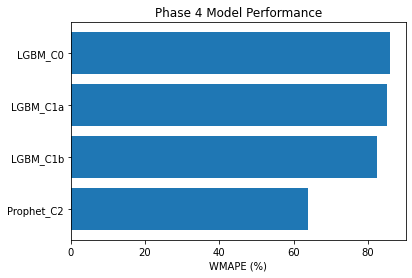

In [20]:
import matplotlib.pyplot as plt

plot_df = final_results.sort_values("WMAPE_pct")

plt.figure()
plt.barh(plot_df["model"], plot_df["WMAPE_pct"])
plt.xlabel("WMAPE (%)")
plt.title("Phase 4 Model Performance")
plt.show()

# Phase 5 — Evaluation and Final Comparison

In Phase 5, we compare the Phase 4 primary models against the strongest Phase 3 baseline for each cluster. The goal is to create a clean evaluation table and visualization for the final report/presentation.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("../data")
OUT = DATA / "primary_models"

phase5_out = DATA / "phase5_evaluation"
phase5_out.mkdir(exist_ok=True)

In [23]:
# Load Phase 4 metrics
phase4 = pd.read_csv(OUT / "phase4_primary_model_metrics.csv")

phase4

,model,n_rows,n_products,WMAPE,eps_MAPE,NZ_MAPE,MAE,zero_rate,WMAPE_pct,eps_MAPE_pct,NZ_MAPE_pct
0,Prophet_C2,1570,10,0.638486,10.357332,1.618752,506.809242,0.033758,63.848631,1035.733156,161.875165
1,LGBM_C1b,24492,156,0.824270,1.411377,0.918691,15.211351,0.653275,82.427011,141.137727,91.869111
2,LGBM_C1a,49769,317,0.851104,1.114611,0.956417,11.351459,0.722377,85.110433,111.461123,95.641678
3,LGBM_C0,80855,515,0.858990,2.175075,0.949378,20.051437,0.491596,85.899041,217.507516,94.937836
4,Prophet_C1a,49769,317,1.205199,5.071062,1.851499,16.074142,0.722377,120.519940,507.106154,185.149902


In [24]:
# Baseline values from Phase 3
baseline_df = pd.DataFrame([
    {"cluster": "C0", "baseline_model": "TSB", "baseline_WMAPE": 108.0},
    {"cluster": "C1a", "baseline_model": "iMAPA", "baseline_WMAPE": 95.8},
    {"cluster": "C1b", "baseline_model": "iMAPA", "baseline_WMAPE": 102.9},
    {"cluster": "C2", "baseline_model": "AutoETS", "baseline_WMAPE": 93.9},
    {"cluster": "C3", "baseline_model": "iMAPA", "baseline_WMAPE": 110.5},
    {"cluster": "C4", "baseline_model": "SWLY", "baseline_WMAPE": 116.6},
])

baseline_df

,cluster,baseline_model,baseline_WMAPE
0,C0,TSB,108.0
1,C1a,iMAPA,95.8
2,C1b,iMAPA,102.9
3,C2,AutoETS,93.9
4,C3,iMAPA,110.5
5,C4,SWLY,116.6


In [25]:
# Keep only final Phase 4 models
# Prophet_C1a was tested but rejected, so we exclude it from the final comparison.

final_model_map = {
    "LGBM_C0": "C0",
    "LGBM_C1a": "C1a",
    "LGBM_C1b": "C1b",
    "Prophet_C2": "C2",
}

final_models = phase4[phase4["model"].isin(final_model_map.keys())].copy()
final_models["cluster"] = final_models["model"].map(final_model_map)

final_models["final_WMAPE"] = final_models["WMAPE"] * 100
final_models = final_models[["cluster", "model", "final_WMAPE", "eps_MAPE_pct", "NZ_MAPE_pct", "MAE"]]

final_models

,cluster,model,final_WMAPE,eps_MAPE_pct,NZ_MAPE_pct,MAE
0,C2,Prophet_C2,63.848631,1035.733156,161.875165,506.809242
1,C1b,LGBM_C1b,82.427011,141.137727,91.869111,15.211351
2,C1a,LGBM_C1a,85.110433,111.461123,95.641678,11.351459
3,C0,LGBM_C0,85.899041,217.507516,94.937836,20.051437


In [26]:
# Merge baseline and final model results
comparison_final = baseline_df.merge(final_models, on="cluster", how="left")

# Add retained models for C3 and C4
comparison_final.loc[comparison_final["cluster"] == "C3", "model"] = "iMAPA retained"
comparison_final.loc[comparison_final["cluster"] == "C3", "final_WMAPE"] = 110.5

comparison_final.loc[comparison_final["cluster"] == "C4", "model"] = "SWLY retained"
comparison_final.loc[comparison_final["cluster"] == "C4", "final_WMAPE"] = 116.6

comparison_final["improvement_points"] = (
    comparison_final["baseline_WMAPE"] - comparison_final["final_WMAPE"]
)

comparison_final["pct_reduction"] = (
    comparison_final["improvement_points"] / comparison_final["baseline_WMAPE"] * 100
)

comparison_final["beats_baseline"] = comparison_final["final_WMAPE"] < comparison_final["baseline_WMAPE"]

comparison_final = comparison_final[
    [
        "cluster",
        "baseline_model",
        "baseline_WMAPE",
        "model",
        "final_WMAPE",
        "improvement_points",
        "pct_reduction",
        "beats_baseline",
    ]
]

comparison_final

,cluster,baseline_model,baseline_WMAPE,model,final_WMAPE,improvement_points,pct_reduction,beats_baseline
0,C0,TSB,108.0,LGBM_C0,85.899041,22.100959,20.463850,True
1,C1a,iMAPA,95.8,LGBM_C1a,85.110433,10.689567,11.158212,True
2,C1b,iMAPA,102.9,LGBM_C1b,82.427011,20.472989,19.896005,True
3,C2,AutoETS,93.9,Prophet_C2,63.848631,30.051369,32.003588,True
4,C3,iMAPA,110.5,iMAPA retained,110.500000,0.000000,0.000000,False
5,C4,SWLY,116.6,SWLY retained,116.600000,0.000000,0.000000,False


In [27]:
# Save final comparison table
comparison_final.to_csv(phase5_out / "phase5_final_comparison.csv", index=False)
comparison_final.to_parquet(phase5_out / "phase5_final_comparison.parquet", index=False)

print("Saved final Phase 5 comparison table.")

Saved final Phase 5 comparison table.


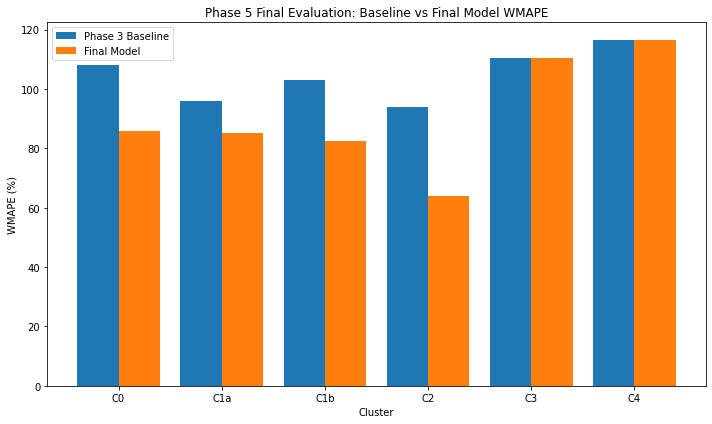

In [28]:
# Bar chart: Baseline vs Final WMAPE

plot_df = comparison_final.copy()

x = range(len(plot_df))

plt.figure(figsize=(10, 6))
plt.bar([i - 0.2 for i in x], plot_df["baseline_WMAPE"], width=0.4, label="Phase 3 Baseline")
plt.bar([i + 0.2 for i in x], plot_df["final_WMAPE"], width=0.4, label="Final Model")

plt.xticks(x, plot_df["cluster"])
plt.ylabel("WMAPE (%)")
plt.xlabel("Cluster")
plt.title("Phase 5 Final Evaluation: Baseline vs Final Model WMAPE")
plt.legend()
plt.tight_layout()

plt.savefig(phase5_out / "baseline_vs_final_wmape.png", dpi=300)
plt.show()

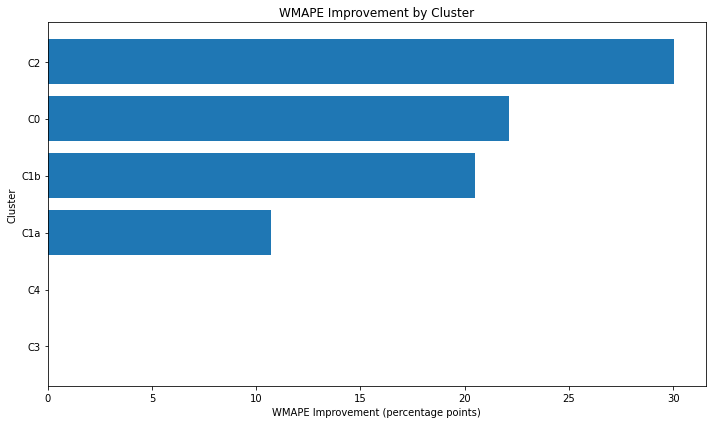

In [29]:
# Improvement chart

improve_df = comparison_final.sort_values("improvement_points", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(improve_df["cluster"], improve_df["improvement_points"])
plt.xlabel("WMAPE Improvement (percentage points)")
plt.ylabel("Cluster")
plt.title("WMAPE Improvement by Cluster")
plt.tight_layout()

plt.savefig(phase5_out / "wmape_improvement_by_cluster.png", dpi=300)
plt.show()

In [31]:

comparison_display = comparison_final.copy()

for col in ["baseline_WMAPE", "final_WMAPE", "improvement_points", "pct_reduction"]:
    comparison_display[col] = comparison_display[col].round(1)

comparison_display

,cluster,baseline_model,baseline_WMAPE,model,final_WMAPE,improvement_points,pct_reduction,beats_baseline
0,C0,TSB,108.0,LGBM_C0,85.9,22.1,20.5,True
1,C1a,iMAPA,95.8,LGBM_C1a,85.1,10.7,11.2,True
2,C1b,iMAPA,102.9,LGBM_C1b,82.4,20.5,19.9,True
3,C2,AutoETS,93.9,Prophet_C2,63.8,30.1,32.0,True
4,C3,iMAPA,110.5,iMAPA retained,110.5,0.0,0.0,False
5,C4,SWLY,116.6,SWLY retained,116.6,0.0,0.0,False


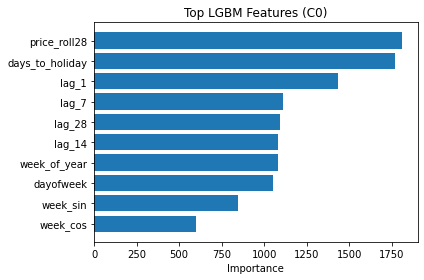

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Load feature importance
fi = pd.read_csv("../data/primary_models/c0_lgbm_feature_importance.csv")

# Top 10 features
fi = fi.sort_values("importance", ascending=False).head(10)

plt.figure()
plt.barh(fi["feature"], fi["importance"])
plt.gca().invert_yaxis()
plt.title("Top LGBM Features (C0)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()